# Multivavariate regression

We aim to explore the following question: 

*Is there a specific aspect and consideration that my impact the purchase of a property?*


## Methodologies
We sample all the properties exchanged between 2001 and 2017 in Newcastle-Upon-Tyne to explore the feasibility of answer the above question. The size and complexity of the data is reduced.  

Dependent variable: 

- The **price** at the time of exchange is the dependent variable.

Independent variables:

- *month of the sale*
- *year of the sale*
- *whether a house is newly built or not*
- *the type of property*
- *whether it is a freehold or a leasehold*.
    
We apply a multivariate analysis with the following hypothesis. We imply that none of the independent variables are significantly related to the dependent variable.

$H_0$ : *All regression coefficients (β) for the independent variables are equal to zero.*

$H_1$ : *At least one regression coefficient is not equal to zero.*

We chose a p-value of 0.05, to test the statistical significance. 

## Interpretation 

We discover some collinearity may be cause by the _year_ variable. Therefore, we remove it from our analysis. 


month : The p-value is 0.105, which greater than 0.05. This means the variable month is not statistically significant in this model. Its relationship with Price could be due to random chance.

Type of property : The p-value is 0.000, which is much less than 0.05. This means the type of property is a statistically significant predictor of prices.

Duration :  The p-value is 0.000, which is much less than 0.05. This means the type of duration is a statistically significant predictor of prices.


It is worth noting, the prices varies for each indepdendent variable. The volatibility in the data suggests its complexity needs lowered 

# Upload libraries and data 

In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import statsmodels.api as sm
import statsmodels.formula.api as smf 
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from scipy.stats import pearsonr


import matplotlib.pyplot as plt


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/united-kingdom-real-estate-and-population-data/data.csv


In [38]:
from IPython.core.display import HTML 
def short_summary(est): 
    return HTML(est.summary().tables[1].as_html()) 

# Data Cleaning

We clean the data by reducing the size of the dataset between from neary 8 million to 100,000 observations.  The exploration can be extended to other location and compared at a later stage. 

In [39]:
data = pd.read_csv('/kaggle/input/united-kingdom-real-estate-and-population-data/data.csv')
print(data.shape)
data.dtypes

(7853837, 13)


Unnamed: 0            int64
Code                 object
Name                 object
Geography            object
Area (sq km)        float64
Price                 int64
Date of Transfer     object
Property Type        object
Old/New              object
Duration             object
PPDCategory Type     object
pp_sq_m             float64
est_pop             float64
dtype: object

In [40]:
filter = (data.Name == 'NEWCASTLE UPON TYNE')
data_new = data.loc[filter,: ].copy(deep = True)
data_new.shape

(102808, 13)

In [41]:
data_new.columns

Index(['Unnamed: 0', 'Code', 'Name', 'Geography', 'Area (sq km)', 'Price',
       'Date of Transfer', 'Property Type', 'Old/New', 'Duration',
       'PPDCategory Type', 'pp_sq_m', 'est_pop'],
      dtype='object')

In [42]:
columns = ['Price','Property Type', 'Old/New', 'Duration', 'Date of Transfer']
data_new = data_new.loc[:, columns]
data_new.head()

,Price,Property Type,Old/New,Duration,Date of Transfer
132800,112000,S,Y,F,2001-11-16
132801,62500,F,N,L,2001-07-30
132802,72500,T,N,F,2001-06-15
132803,35000,F,N,L,2001-04-27
132804,113000,F,N,F,2001-10-31


In [43]:
data_new['date'] = pd.to_datetime(data_new['Date of Transfer'])
data_new['month'] = data_new['date'].dt.month
data_new['year'] = data_new['date'].dt.year
data_new


,Price,Property Type,Old/New,Duration,Date of Transfer,date,month,year
132800,112000,S,Y,F,2001-11-16,2001-11-16,11,2001
132801,62500,F,N,L,2001-07-30,2001-07-30,7,2001
132802,72500,T,N,F,2001-06-15,2001-06-15,6,2001
132803,35000,F,N,L,2001-04-27,2001-04-27,4,2001
132804,113000,F,N,F,2001-10-31,2001-10-31,10,2001
...,...,...,...,...,...,...,...,...
5299753,112995,F,Y,L,2017-02-27,2017-02-27,2,2017
5299754,284995,D,Y,L,2017-02-03,2017-02-03,2,2017
5299755,129995,T,Y,L,2017-02-10,2017-02-10,2,2017
5299756,208995,S,Y,L,2017-03-07,2017-03-07,3,2017


In [44]:
data_new['Old/New'] = data_new['Old/New'].astype('category')
data_new['old_new_codes'] = data_new['Old/New'].cat.codes
data_new['Property Type'] = data_new['Property Type'].astype('category')
data_new['property_types_codes'] = data_new['Property Type'].cat.codes
data_new['Duration'] = data_new['Duration'].astype('category')
data_new['duration_code'] = data_new['Duration'].cat.codes
data_new['Price_log'] = np.log10(data_new['Price'])
data_new.head()


,Price,Property Type,Old/New,Duration,Date of Transfer,date,month,year,old_new_codes,property_types_codes,duration_code,Price_log
132800,112000,S,Y,F,2001-11-16,2001-11-16,11,2001,1,3,0,5.049218
132801,62500,F,N,L,2001-07-30,2001-07-30,7,2001,0,1,1,4.795880
132802,72500,T,N,F,2001-06-15,2001-06-15,6,2001,0,4,0,4.860338
132803,35000,F,N,L,2001-04-27,2001-04-27,4,2001,0,1,1,4.544068
132804,113000,F,N,F,2001-10-31,2001-10-31,10,2001,0,1,0,5.053078


In [45]:
data_new = data_new.dropna()

# Data summary
We summarise the property prices across the sample. The expected sample mean is approximately 163000 (GBP) with a standard deviation of 443,000 (GBP) approximately. The prices suffers from a high level of volatibility - a coefficient of variation of 231% exists. 

The property prices suffers from a large kurtosis (5035.69), having an excess of tail against the Normal Distribution.  A histogram and a boxplot (log scale) indicates prices varies between 1e0 to 4.62e7 (GBP) - a rather excessive tails at each end. 

Those findings are likely to impact negatively on the analysis as well as the multivariate regression. A possible relationship may be harder to establish.

In [46]:
data_new.describe()['Price']

count    1.028080e+05
mean     1.633868e+05
min      1.000000e+00
25%      8.500000e+04
50%      1.280000e+05
75%      1.850000e+05
max      7.493716e+07
std      4.428592e+05
Name: Price, dtype: float64

In [47]:
data_new['Price'].kurt()

10534.11353544135

In [48]:
CV = (data_new.describe()['Price']['std']/data_new.describe()['Price']['mean'])*100
CV

271.0495479240116

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


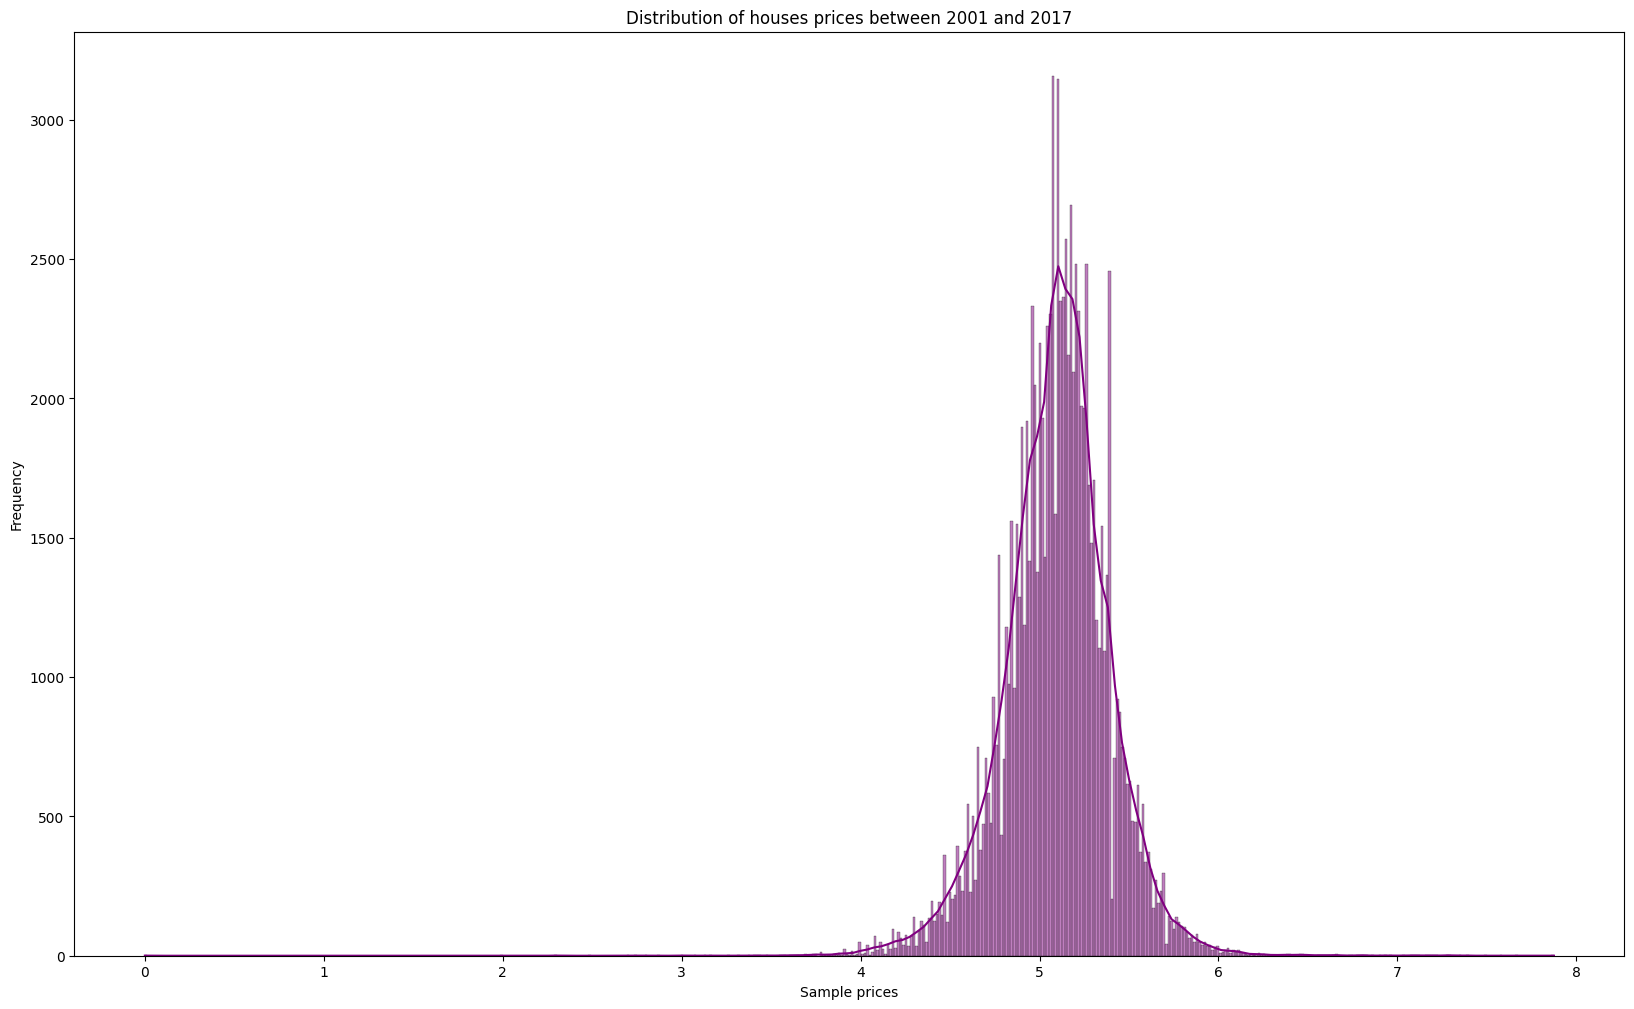

In [49]:
plt.figure(figsize=(20, 12))
sns.histplot(data=data_new, x='Price_log', kde = True,color='purple')
plt.title('Distribution of houses prices between 2001 and 2017')
plt.xlabel('Sample prices')
plt.ylabel('Frequency')
plt.show()

In [50]:
data_new.groupby(['Duration']).describe()['Price']


/tmp/ipykernel_324/777111626.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_new.groupby(['Duration']).describe()['Price']


,count,mean,min,25%,50%,75%,max,std
Duration,,,,,,,,
F,64736.0,180881.737565,1.0,90000.0,135997.5,209837.5,74937156.0,503344.192151
L,38071.0,133640.137427,100.0,78000.0,119500.0,162068.0,31600000.0,312109.141559
U,1.0,96000.000000,96000.0,96000.0,96000.0,96000.0,96000.0,NaN


<Axes: >

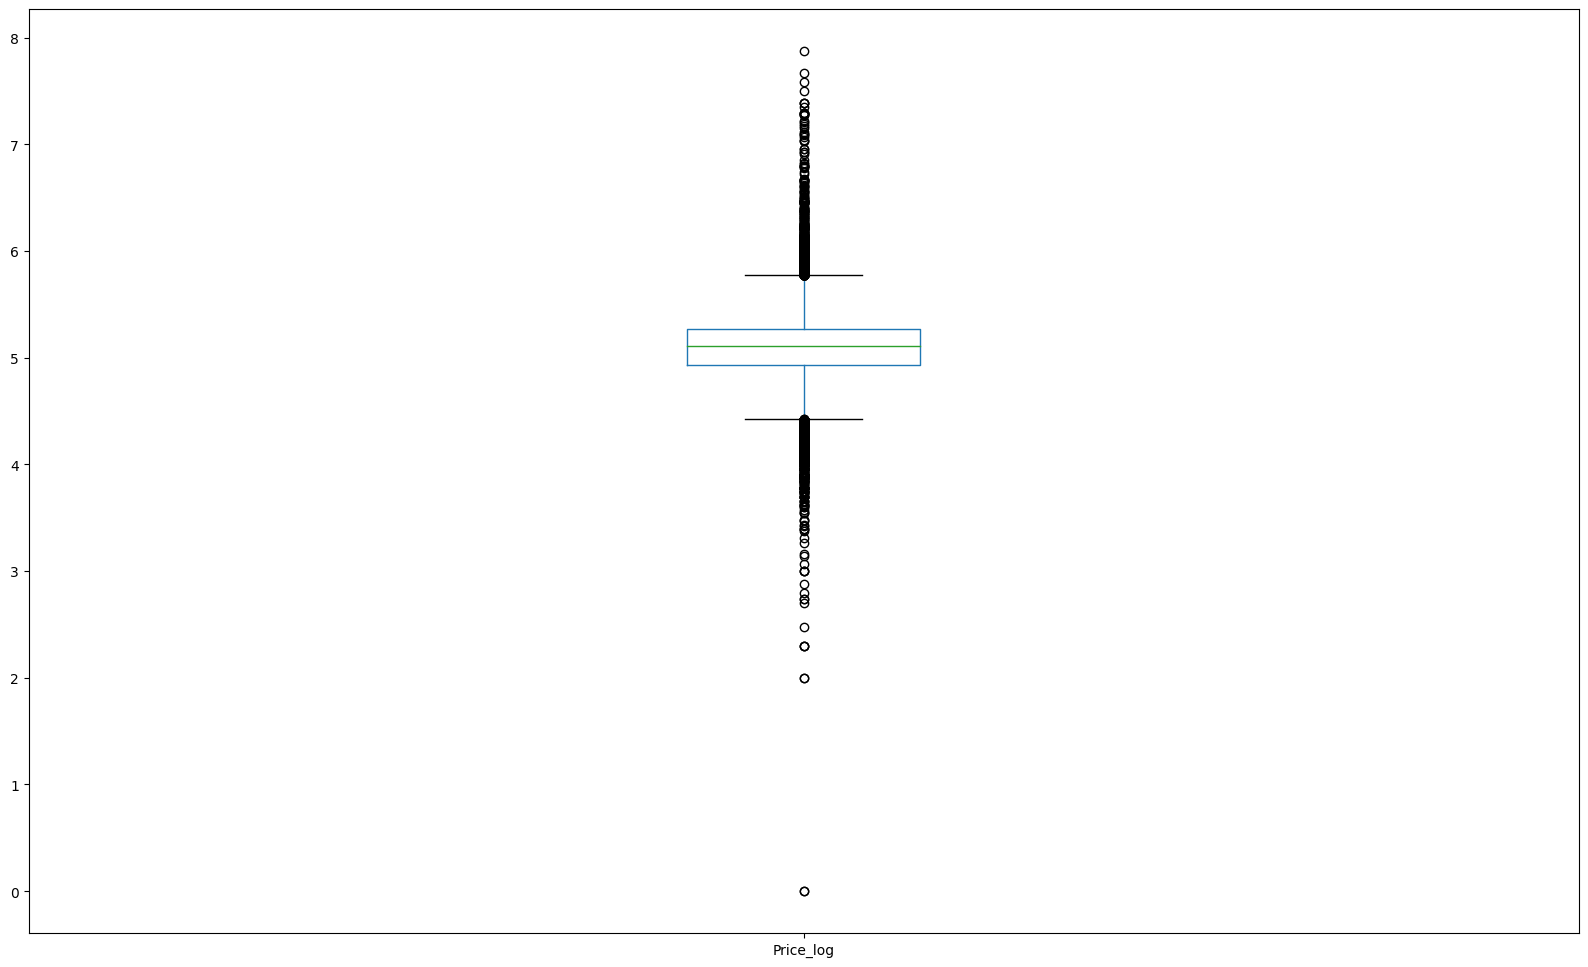

In [51]:
data_new.boxplot(column =['Price_log'], figsize= (20, 12), grid=False)

# Are all the variables independent? 

We explore if any variables are dependent from each other.  A correlation matrix suggests most of the independent and dependent variables have not linear relationship, Pearson correlations is small than $0.10$ or $-0.10$.  The relationship between a new built and a lease or freehold exists - negatively impacting on a multivariate analys.  



In [52]:
columns = ['Price', 'month', 'year', 'old_new_codes', 'property_types_codes',
       'duration_code']
data_new = data_new.loc[:, columns]
filter 
data_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102808 entries, 132800 to 5299757
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Price                 102808 non-null  int64
 1   month                 102808 non-null  int32
 2   year                  102808 non-null  int32
 3   old_new_codes         102808 non-null  int8 
 4   property_types_codes  102808 non-null  int8 
 5   duration_code         102808 non-null  int8 
dtypes: int32(2), int64(1), int8(3)
memory usage: 2.6 MB


In [53]:
data_new.corr()

,Price,month,year,old_new_codes,property_types_codes,duration_code
Price,1.000000,0.005693,0.089508,0.018233,-0.061358,-0.051514
month,0.005693,1.000000,-0.043086,0.034526,-0.002892,-0.004212
year,0.089508,-0.043086,1.000000,0.043890,-0.003935,-0.031878
old_new_codes,0.018233,0.034526,0.043890,1.000000,-0.177980,0.107645
property_types_codes,-0.061358,-0.002892,-0.003935,-0.177980,1.000000,-0.403835
duration_code,-0.051514,-0.004212,-0.031878,0.107645,-0.403835,1.000000


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

<Figure size 2000x1200 with 0 Axes>

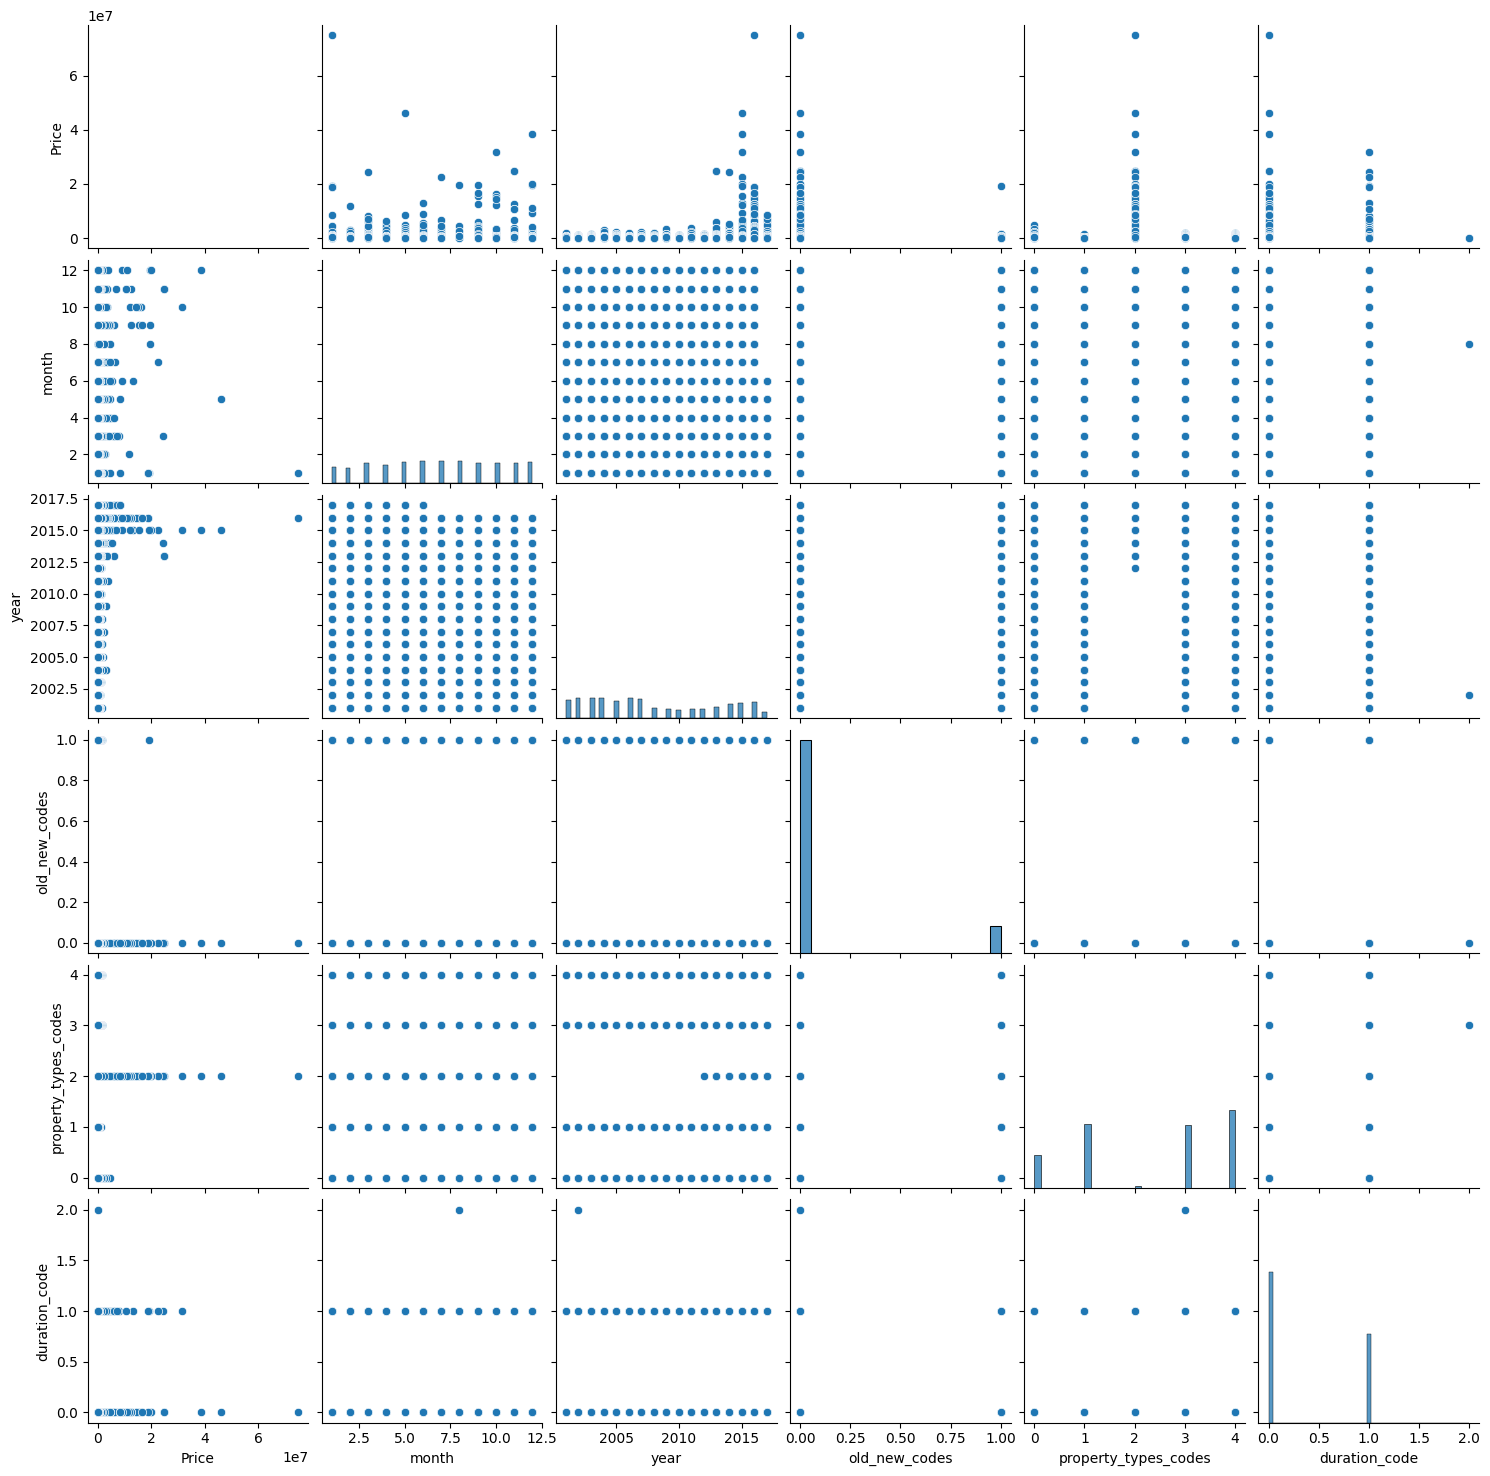

In [54]:
plt.figure(figsize=(20, 12))
sns.pairplot(data_new)
plt.show()

In [55]:
X = data_new

# Add a constant term for the VIF calculation
X = sm.add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

                feature            VIF
0                 const  166567.675360
1                 Price       1.018623
2                 month       1.003363
3                  year       1.013066
4         old_new_codes       1.037939
5  property_types_codes       1.230995
6         duration_code       1.206490


# Regression analysis

We discover some collinearity may be cause by the _year_ variable. Therefore, we remove it from our analysis. 


month : The p-value is 0.105, which greater than 0.05. This means the variable month is not statistically significant in this model. Its relationship with Price could be due to random chance.

Type of property : The p-value is 0.000, which is much less than 0.05. This means the type of property is a statistically significant predictor of prices.

Duration :  The p-value is 0.000, which is much less than 0.05. This means the type of duration is a statistically significant predictor of prices.


It is worth noting, the prices varies for each indepdendent variable. The volatibility in the data suggests its complexity needs lowered. 

In [56]:
data_new.info()


<class 'pandas.core.frame.DataFrame'>
Index: 102808 entries, 132800 to 5299757
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Price                 102808 non-null  int64
 1   month                 102808 non-null  int32
 2   year                  102808 non-null  int32
 3   old_new_codes         102808 non-null  int8 
 4   property_types_codes  102808 non-null  int8 
 5   duration_code         102808 non-null  int8 
dtypes: int32(2), int64(1), int8(3)
memory usage: 2.6 MB


In [57]:
data_new['Price_log'] = np.log10(data_new['Price'])

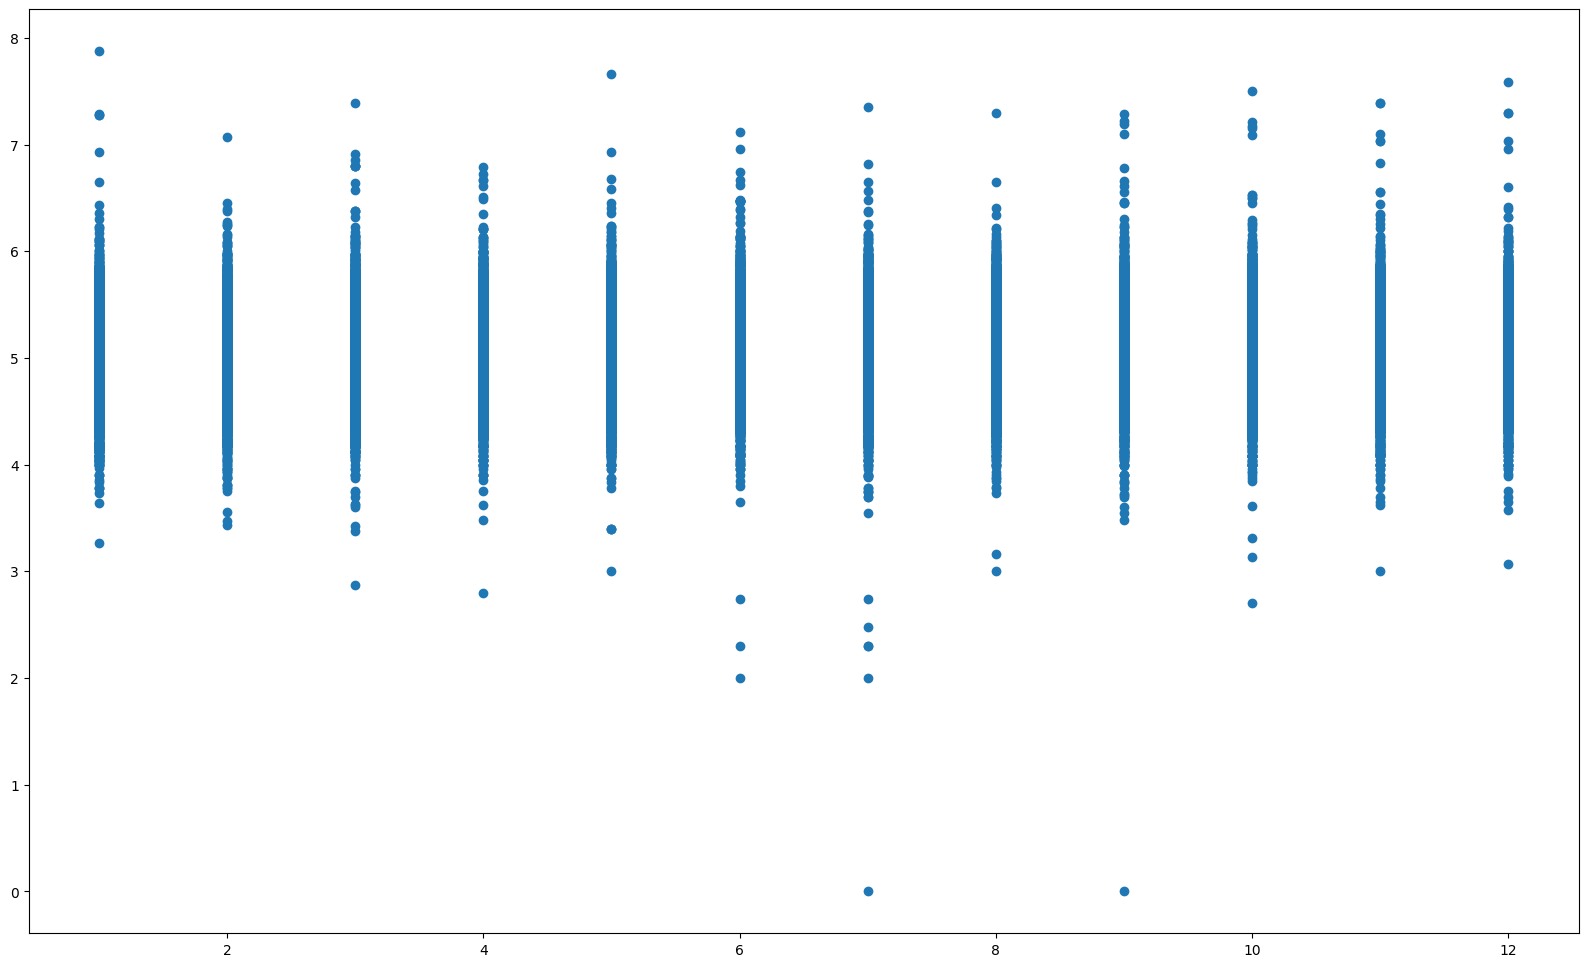

In [58]:
plt.figure(figsize=(20, 12))
plt.scatter(data_new['month'], data_new['Price_log'])

In [59]:
est = smf.ols(formula='Price ~ month', data=data_new).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     3.332
Date:                Sat, 09 Aug 2025   Prob (F-statistic):             0.0679
Time:                        13:59:42   Log-Likelihood:            -1.4825e+06
No. Observations:              102808   AIC:                         2.965e+06
Df Residuals:                  102806   BIC:                         2.965e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.583e+05   3113.180     50.846      0.000    1.52e+05    1.64e+05
month        756.8230    414.583      1.826      0.068     -55.755    1569.401
==============================================================================
Omnibus:                   385655.298   Durbin-Watson:                   1.929
Prob(Omnibus):                  0.000   Jarque-Bera (JB):     475623835474.826
Skew:                          83.693   Prob(JB):                         0.00
Kurtosis:                   10538.840   Cond. No.                         17.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

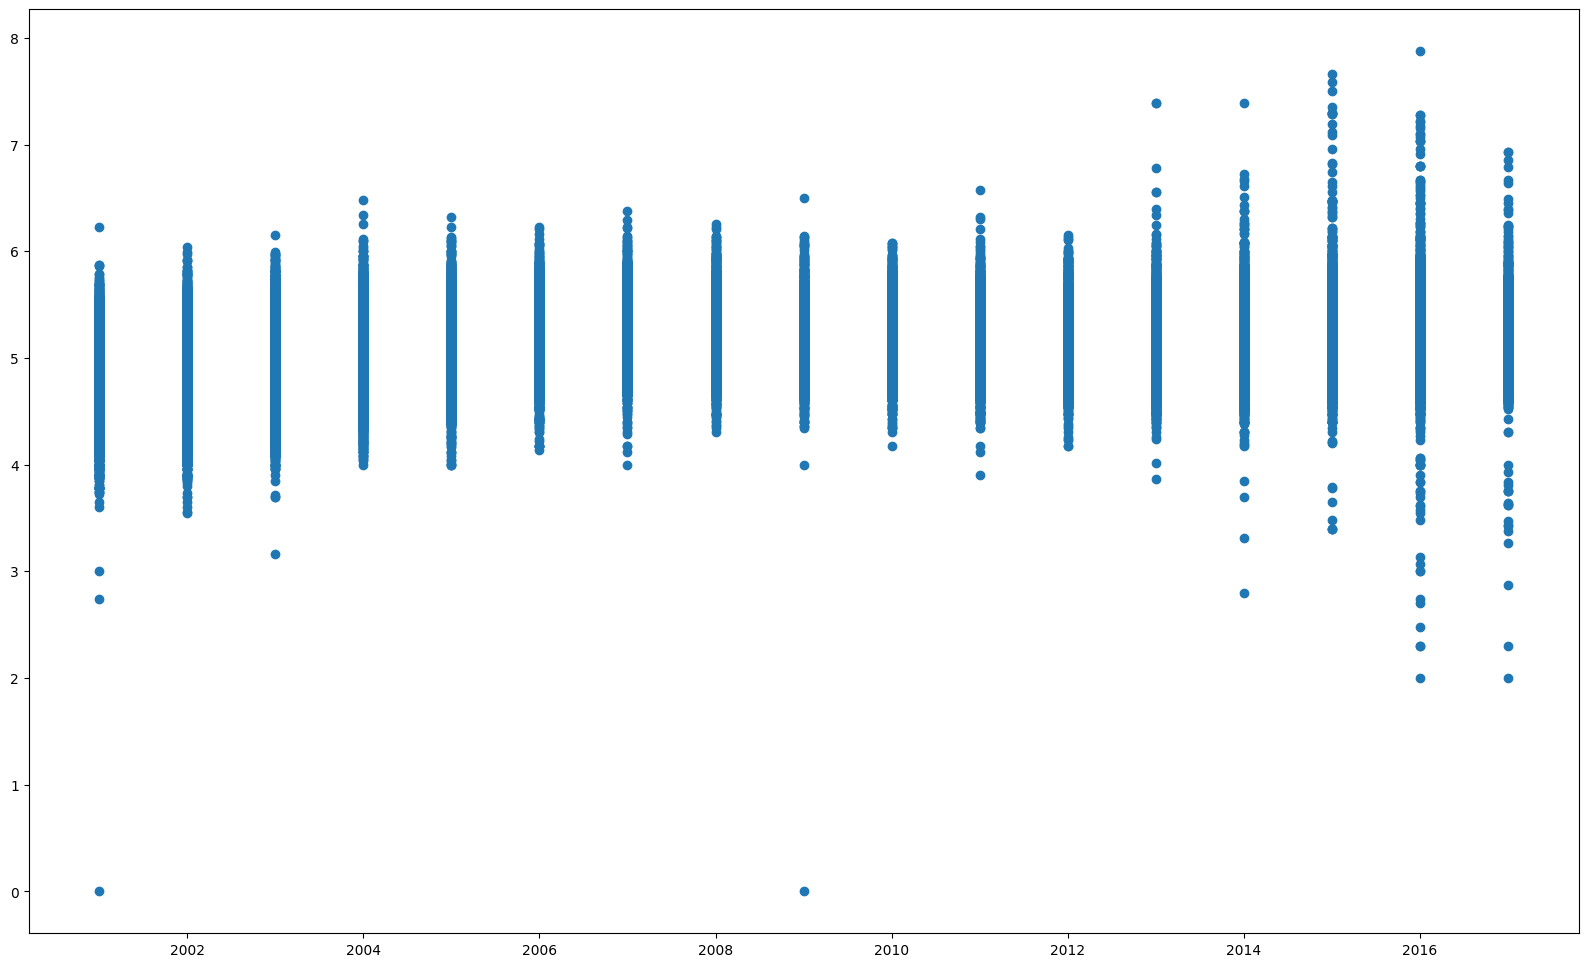

In [74]:
plt.figure(figsize=(20, 12))
plt.scatter(data_new['year'], data_new['Price_log'])

In [73]:
est = smf.ols(formula='Price ~ year', data=data_new).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     830.3
Date:                Sat, 09 Aug 2025   Prob (F-statistic):          7.40e-182
Time:                        14:14:31   Log-Likelihood:            -1.4821e+06
No. Observations:              102808   AIC:                         2.964e+06
Df Residuals:                  102806   BIC:                         2.964e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.591e+07   5.58e+05    -28.522      0.000    -1.7e+07   -1.48e+07
year        8003.2947    277.747     28.815      0.000    7458.914    8547.676
==============================================================================
Omnibus:                   386585.645   Durbin-Watson:                   1.944
Prob(Omnibus):                  0.000   Jarque-Bera (JB):     486687987933.609
Skew:                          84.318   Prob(JB):                         0.00
Kurtosis:                   10660.691   Cond. No.                     8.14e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.14e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

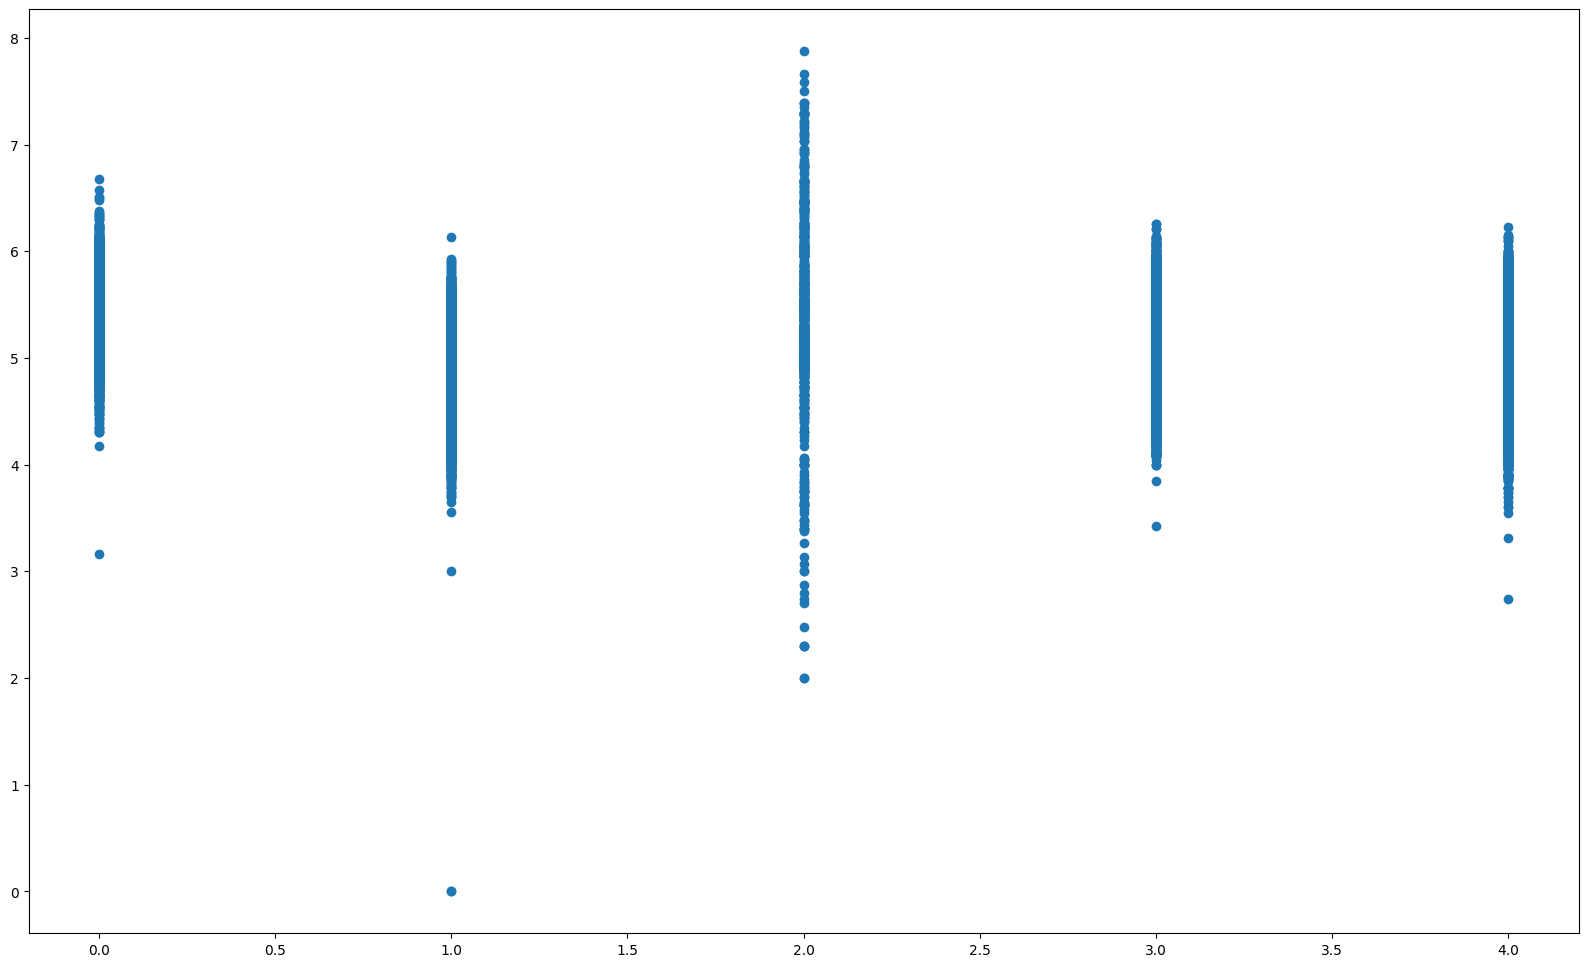

In [75]:
plt.figure(figsize=(20, 12))
plt.scatter(data_new['property_types_codes'], data_new['Price_log'])

In [63]:
est = smf.ols(formula='Price ~ property_types_codes', data=data_new).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     388.5
Date:                Sat, 09 Aug 2025   Prob (F-statistic):           2.53e-86
Time:                        14:02:16   Log-Likelihood:            -1.4823e+06
No. Observations:              102808   AIC:                         2.965e+06
Df Residuals:                  102806   BIC:                         2.965e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             2.065e+05   2585.643     79.865      0.000    2.01e+05    2.12e+05
property_types_codes -1.818e+04    922.431    -19.711      0.000      -2e+04   -1.64e+04
==============================================================================
Omnibus:                   386274.595   Durbin-Watson:                   1.929
Prob(Omnibus):                  0.000   Jarque-Bera (JB):     482181542523.485
Skew:                          84.109   Prob(JB):                         0.00
Kurtosis:                   10611.228   Cond. No.                         5.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

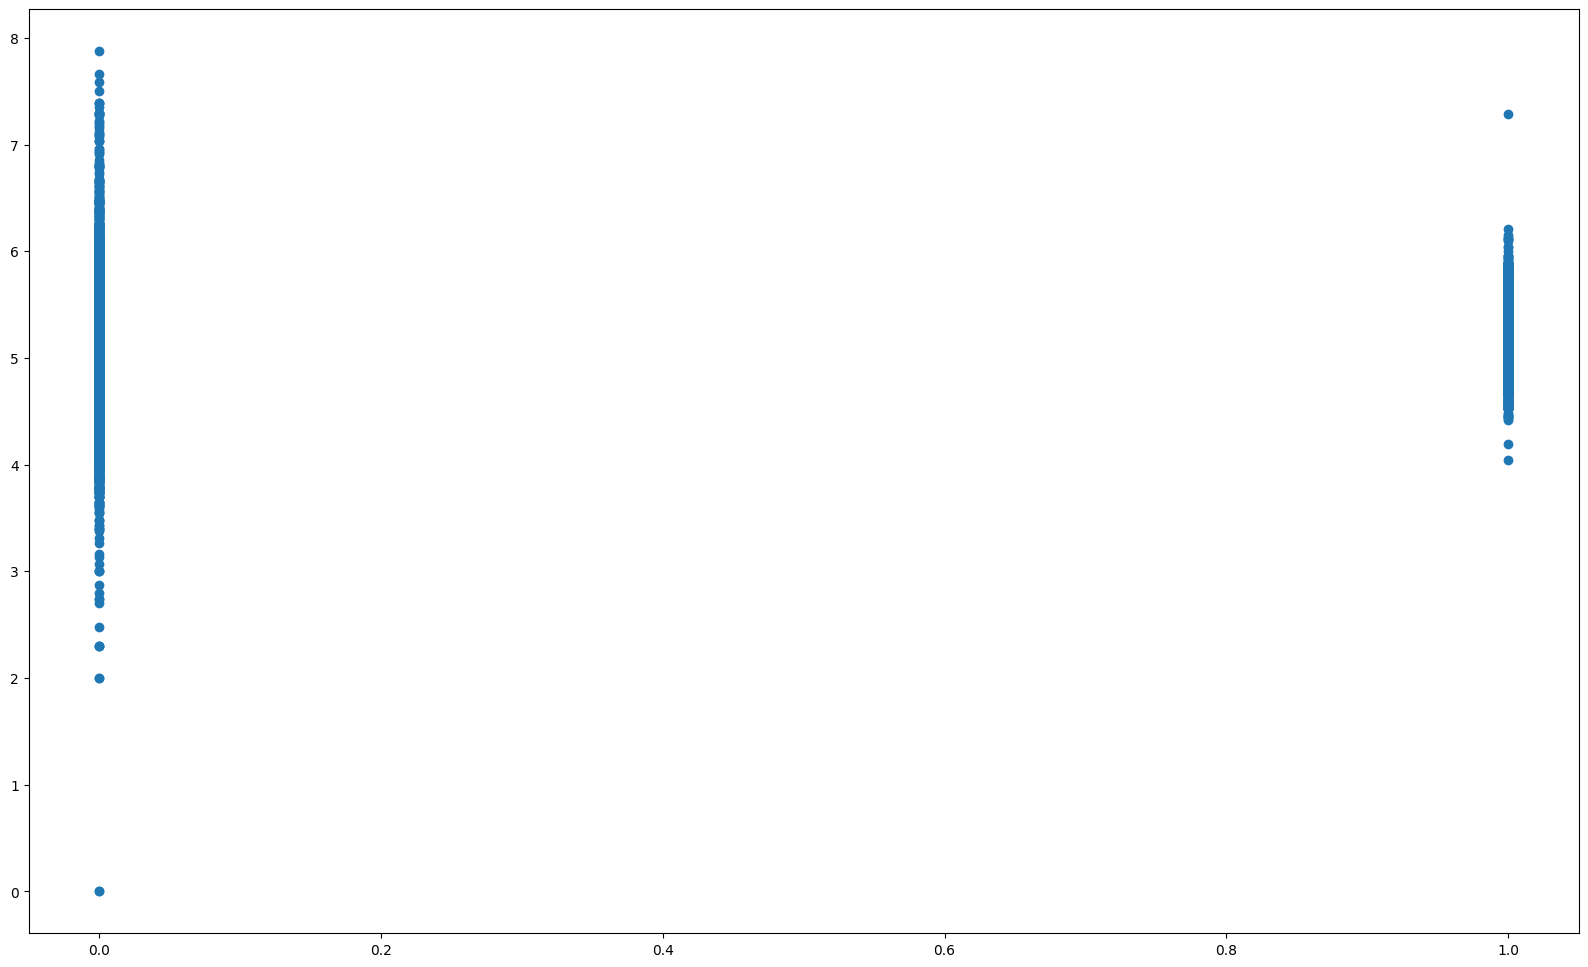

In [76]:
plt.figure(figsize=(20, 12))
plt.scatter(data_new['old_new_codes'], data_new['Price_log'])

In [65]:
est = smf.ols(formula='Price ~ old_new_codes', data=data_new).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     34.19
Date:                Sat, 09 Aug 2025   Prob (F-statistic):           5.02e-09
Time:                        14:02:34   Log-Likelihood:            -1.4825e+06
No. Observations:              102808   AIC:                         2.965e+06
Df Residuals:                  102806   BIC:                         2.965e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      1.605e+05   1464.219    109.643      0.000    1.58e+05    1.63e+05
old_new_codes  2.576e+04   4405.036      5.847      0.000    1.71e+04    3.44e+04
==============================================================================
Omnibus:                   385726.854   Durbin-Watson:                   1.929
Prob(Omnibus):                  0.000   Jarque-Bera (JB):     476232750453.023
Skew:                          83.741   Prob(JB):                         0.00
Kurtosis:                   10545.582   Cond. No.                         3.23
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [69]:
est = smf.ols(formula='Price ~ month + property_types_codes + duration_code', data=data_new).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     372.2
Date:                Sat, 09 Aug 2025   Prob (F-statistic):          1.84e-240
Time:                        14:04:02   Log-Likelihood:            -1.4819e+06
No. Observations:              102808   AIC:                         2.964e+06
Df Residuals:                  102804   BIC:                         2.964e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             2.588e+05   4348.876     59.511      0.000     2.5e+05    2.67e+05
month                  668.0743    412.369      1.620      0.105    -140.164    1476.313
property_types_codes -2.908e+04   1004.791    -28.943      0.000   -3.11e+04   -2.71e+04
duration_code        -8.357e+04   3109.636    -26.874      0.000   -8.97e+04   -7.75e+04
==============================================================================
Omnibus:                   387401.485   Durbin-Watson:                   1.930
Prob(Omnibus):                  0.000   Jarque-Bera (JB):     494182382743.511
Skew:                          84.872   Prob(JB):                         0.00
Kurtosis:                   10742.438   Cond. No.                         27.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [72]:
est = smf.ols(formula='Price ~ property_types_codes + duration_code', data=data_new).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     557.0
Date:                Sat, 09 Aug 2025   Prob (F-statistic):          2.56e-241
Time:                        14:13:32   Log-Likelihood:            -1.4819e+06
No. Observations:              102808   AIC:                         2.964e+06
Df Residuals:                  102805   BIC:                         2.964e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             2.633e+05   3332.749     79.013      0.000    2.57e+05     2.7e+05
property_types_codes -2.909e+04   1004.786    -28.952      0.000   -3.11e+04   -2.71e+04
duration_code         -8.36e+04   3109.607    -26.884      0.000   -8.97e+04   -7.75e+04
==============================================================================
Omnibus:                   387390.400   Durbin-Watson:                   1.930
Prob(Omnibus):                  0.000   Jarque-Bera (JB):     494002129850.394
Skew:                          84.865   Prob(JB):                         0.00
Kurtosis:                   10740.479   Cond. No.                         8.97
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""